In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import json
import numpy as np

In [42]:
# Merge data from corpora
model = 'gpt-4o-mini'

datasets = []
for corpus in ['meco', 'provo']: # 'onestop'
    df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_words_plus_triplets_{model}.csv')
    df['corpus'] = [corpus for i in range(len(df))]
    datasets.append(df)
df = pd.concat(datasets,ignore_index=True)
df.dropna(subset=['n_triplets'], inplace=True)
df['ianum_bin'] = pd.cut(df['ianum'], bins=10)
grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),
                                                  std_triplets=('n_triplets', 'std'),
                                                  count=('ianum', 'count')).reset_index()
grouped['ianum_bin'] = grouped['ianum_bin'].astype(str)

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_29337/2183859823.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),


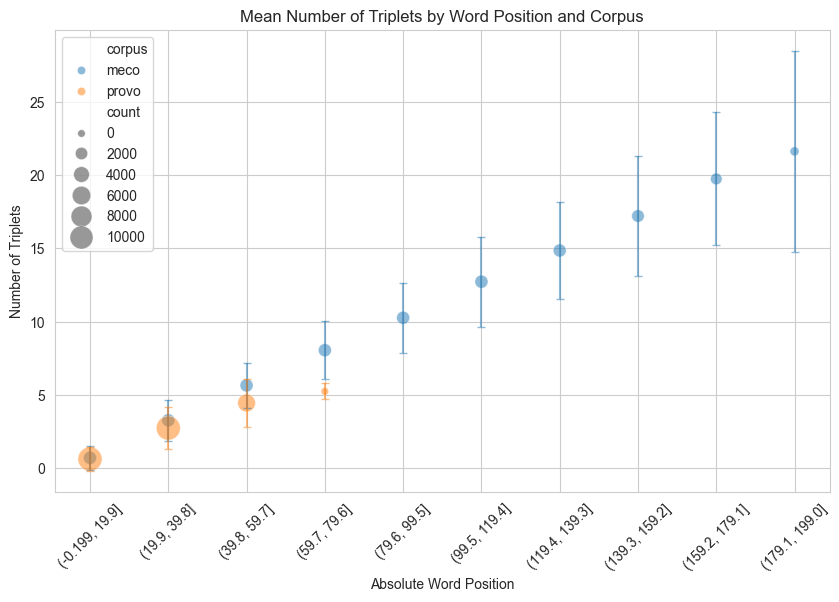

<Figure size 640x480 with 0 Axes>

In [43]:
# Number of triplets per absolute word position in text with size of dots representing data points
# df['ianum_bin'] = df.groupby('corpus')['ianum'].transform(lambda x: pd.cut(x, bins=10))
sns.set_style('whitegrid')
palette = sns.color_palette("tab10", n_colors=grouped['corpus'].nunique())
corpus_colors = dict(zip(grouped['corpus'].unique(), palette))
plt.figure(figsize=(10, 6))
graph = sns.scatterplot(data=grouped, x='ianum_bin', y='mean_triplets', size='count', hue='corpus', sizes=(30, 300), palette=corpus_colors, alpha=0.5)
for i in range(grouped.shape[0]):
    row = grouped.iloc[i]
    plt.errorbar(x=row['ianum_bin'],y=row['mean_triplets'],yerr=row['std_triplets'] if pd.notnull(row['std_triplets']) else 0,
                 fmt='none',ecolor=corpus_colors[row['corpus']],capsize=3, alpha=0.5)
plt.xticks(rotation=45)
plt.title('Mean Number of Triplets by Word Position and Corpus')
plt.xlabel('Absolute Word Position')
plt.ylabel('Number of Triplets')
# plt.tight_layout()
plt.show()

plt.clf()

In [ ]:
# Number of triplets per word position per text in a corpus
corpus_name = 'onestop'
model_name = 'gpt-4o-mini'
df_corpus = pd.read_csv(f'../data/output/{model_name}/{corpus_name}/{corpus_name}_words_plus_triplets_gpt-4o-mini_1_all.csv')
df_corpus.dropna(subset=['n_triplets'], inplace=True)
df_corpus['article_text_id'] = [f'{article_batch}-{article_id}-{difficulty_level}'
                             for article_batch, article_id, difficulty_level in
                             zip(df_corpus['article_batch'].tolist(), df_corpus['article_id'].tolist(),
                                 df_corpus['difficulty_level'].tolist())]
df_corpus['norm_ianum_bin'] = pd.cut(df_corpus['norm_ianum'], bins=[0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1.])
graph = sns.catplot(df_corpus, x='norm_ianum_bin', y='n_triplets', col='article_text_id', col_wrap=5, kind="point")
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()
plt.clf()

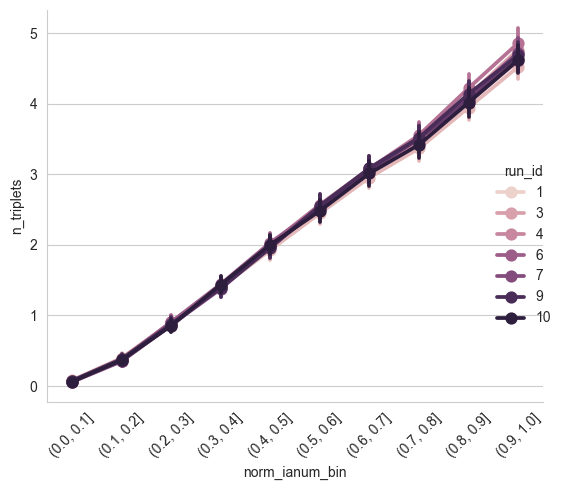

<Figure size 640x480 with 0 Axes>

In [9]:
# Number of triplets per word position in text per run (for one corpus)
corpus_name = 'provo'
model_name = 'gpt-4o-mini'
df_corpus = pd.read_csv(f'../data/output/{model_name}/{corpus_name}/{corpus_name}_words_plus_triplets_{model_name}.csv')
df_corpus.dropna(subset=['n_triplets'], inplace=True)
df_corpus['norm_ianum_bin'] = pd.cut(df_corpus['norm_ianum'], bins=[0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1.])
graph = sns.catplot(df_corpus, x='norm_ianum_bin', y='n_triplets', hue='run_id', kind="point")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.clf()

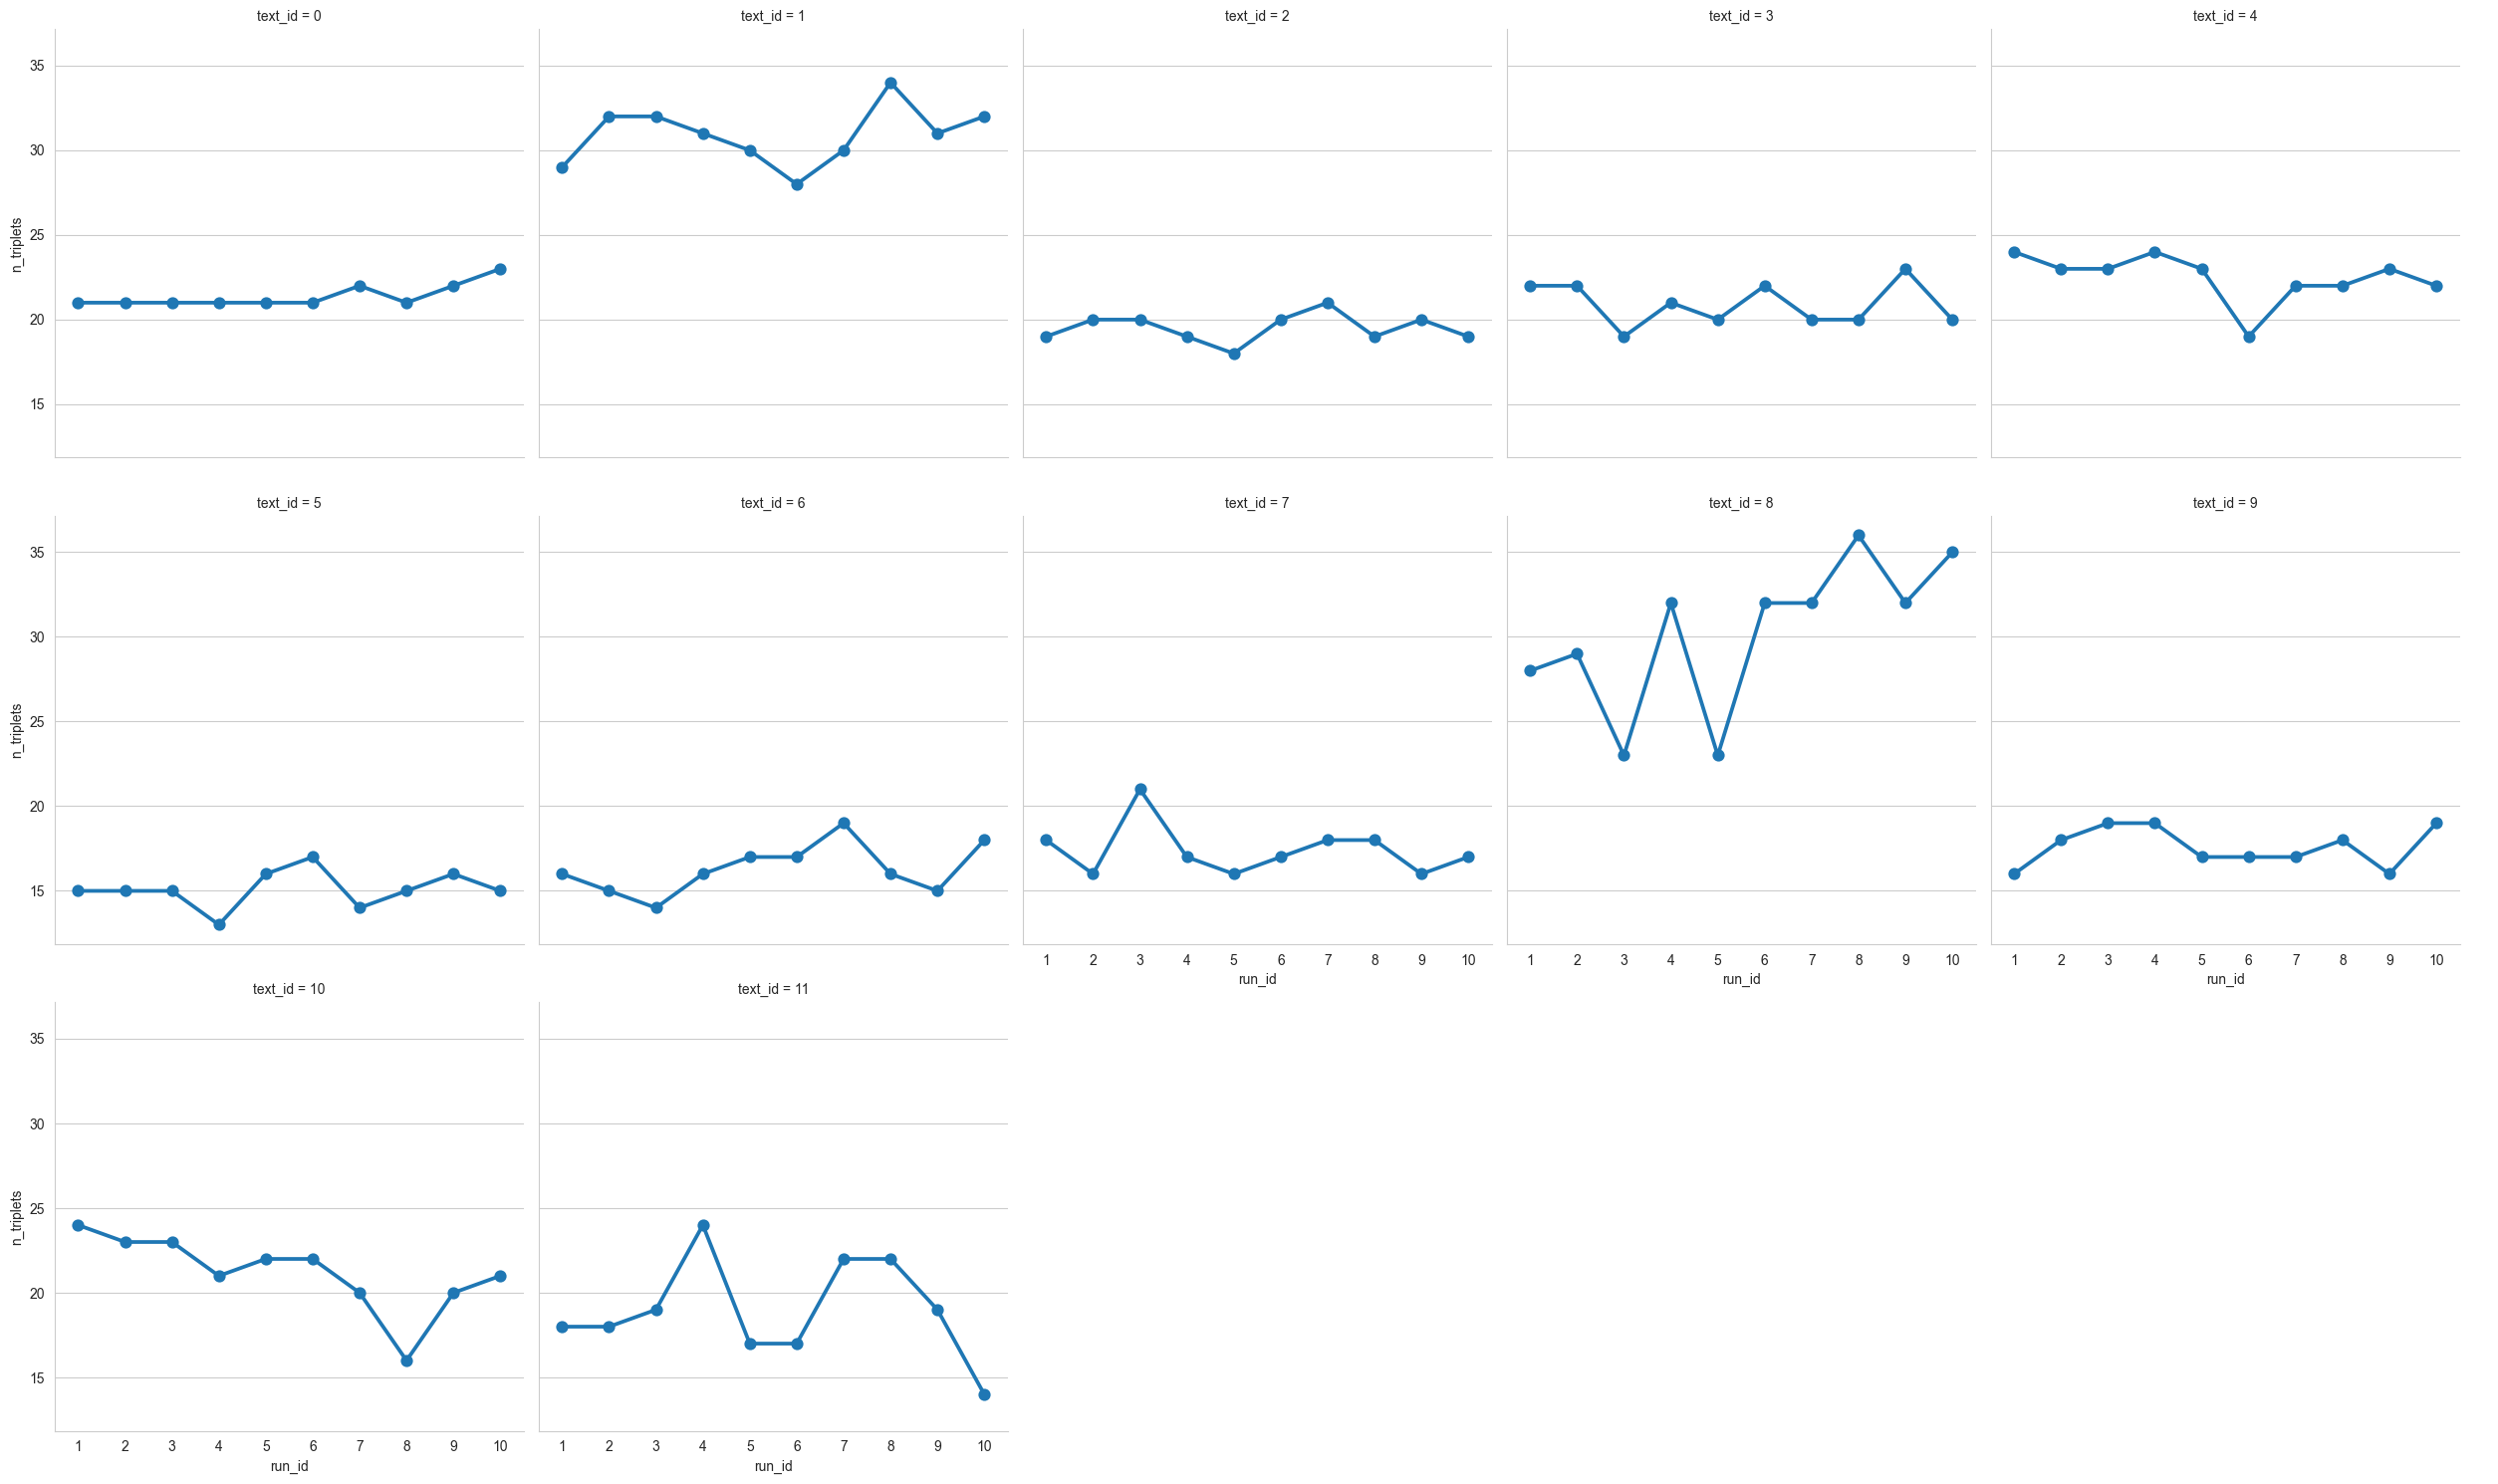

<Figure size 640x480 with 0 Axes>

In [64]:
corpus_name = 'meco'
model_name = 'gpt-4o-mini'
df_corpus = pd.read_csv(f'../data/output/{model_name}/{corpus_name}/{corpus_name}_words_plus_triplets_{model_name}.csv')
df_corpus = df_corpus[df_corpus['norm_ianum']==1]
graph = sns.catplot(df_corpus, x='run_id', y='n_triplets', kind="point", col='text_id', col_wrap=5)
# plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()
plt.clf()

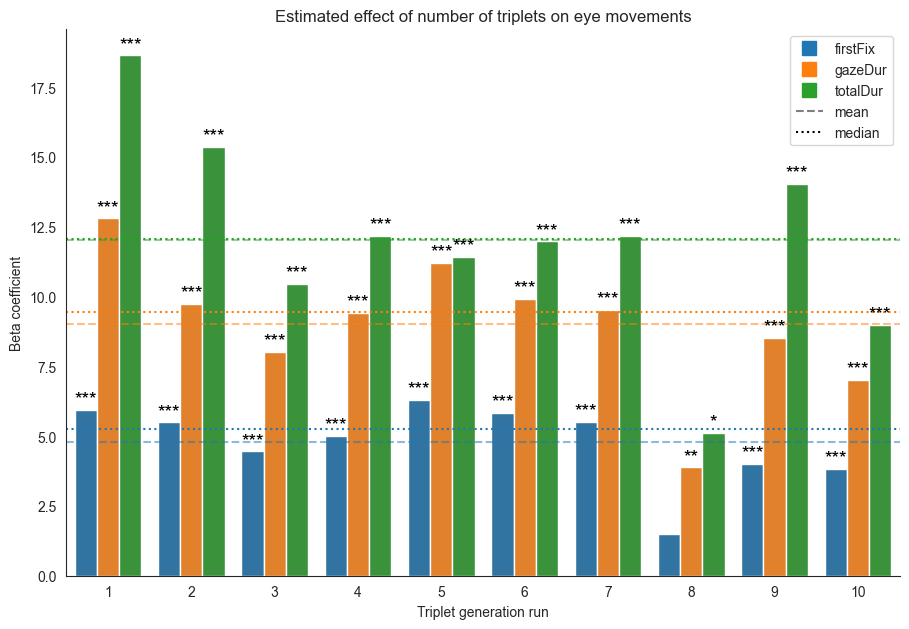

<Figure size 640x480 with 0 Axes>

In [39]:
# Beta coefficients over runs per eye mov measure
n_runs = 10
corpus = 'meco'
model = 'gpt-4o-mini'
IV = 'n_triplets'
DV = ['firstFix', 'gazeDur', 'totalDur']

coefficients, p_values, runs, eye_movs = [], [], [], []

for eye_mov_measure in DV:

    for run in range(1, n_runs+1):

        stats_df = pd.read_csv(f'../data/analysis/{model}/{corpus}/lmer_{eye_mov_measure}Int_{run}.csv')
        coefficient = stats_df[stats_df['term']==IV]['estimate'].values[0]
        p_value =stats_df[stats_df['term']==IV]['p.value'].values[0]
        coefficients.append(coefficient)
        p_values.append(p_value)
        runs.append(run)
        eye_movs.append(eye_mov_measure)

sns.set_style('white')
# plot bars
plot_df = pd.DataFrame({'run': runs, 'coefficient': coefficients, 'p_value': p_values, 'eye_movement_measure': eye_movs})
graph = sns.catplot(data=plot_df, x=runs, y=coefficients, hue=eye_movs, kind='bar', height=6, aspect=1.5, legend=False)

# add significance asterisks
p_thresholds = [(0.001, '***'), (0.01, '**'), (0.05, '*')]
ax = graph.ax
for bar, p_val in zip(ax.patches, plot_df['p_value']):
    significance = ''
    for threshold, symbol in [(0.001, '***'), (0.01, '**'), (0.05, '*')]:
        if p_val < threshold:
            significance = symbol
            break
    if significance:
        x = bar.get_x() + bar.get_width() / 2  # center of the bar
        y = bar.get_height() # top of the bar
        ax.text(x, y + 0.05, significance, ha='center', va='bottom', fontsize=14, color='black')

# add horizontal lines for mean and median
y_positions = {}
for i, eye_mov in enumerate(DV):
    subset = plot_df[plot_df['eye_movement_measure'] == eye_mov]
    mean_val = subset['coefficient'].mean()
    median_val = subset['coefficient'].median()
    ax.axhline(mean_val, color=f'C{i}', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axhline(median_val, color=f'C{i}', linestyle=':', linewidth=1.5)
    # add secondary legend for line styles
    hue_handles = [mlines.Line2D([], [], color=f'C{i}', marker='s', linestyle='None', markersize=10, label=eye_mov) for i, eye_mov in enumerate(DV)]
    mean_line = mlines.Line2D([], [], color='black', linestyle='--', label='mean', alpha=0.5)
    median_line = mlines.Line2D([], [], color='black', linestyle=':', label='median')
    # handles, labels = ax.get_legend_handles_labels()
    # handles.extend([mean_line, median_line])
    # labels.extend(['mean', 'median'])
    handles = hue_handles + [mean_line, median_line]
    labels = [eye_mov for eye_mov in DV] + ['mean', 'median']
    ax.legend(handles=handles, labels=labels, loc='upper right')

# in case we do plots seperatly for each eye mov
# for i, row in plot_df.iterrows():
#     significance = ''
#     for threshold, symbol in p_thresholds:
#         if row['p_value'] < threshold:
#             significance = symbol
#             break
#     if significance:
#         ax.text(i, row['coefficient'] + 0.05, significance, ha='center', va='bottom', fontsize=14, color='black')
# mean_coeff = plot_df['coefficient'].mean()
# median_coeff = plot_df['coefficient'].median()
# ax.axhline(mean_coeff, color='blue', linestyle='--', alpha=0.5, label=f'Mean: {mean_coeff:.2f}')
# ax.axhline(median_coeff, color='orange', linestyle=':', label=f'Median: {median_coeff:.2f}')
# # ax.legend()
# ax.text(n_runs - 0.5, mean_coeff + 0.02, f'Mean: {mean_coeff:.2f}', color='blue', fontsize=12, alpha=0.5, ha='right')
# ax.text(n_runs - 0.5, median_coeff + 0.02, f'Median: {median_coeff:.2f}', color='orange', fontsize=12, ha='right')

# add extra info graph
plt.title(f'Estimated effect of number of triplets on eye movements')
plt.xlabel('Triplet generation run')
plt.ylabel('Beta coefficient')
# plt.tight_layout()
plt.show()
plt.clf()

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_29337/1126660089.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  graph.ax.set_xticklabels(['Number of triplets (NT)',


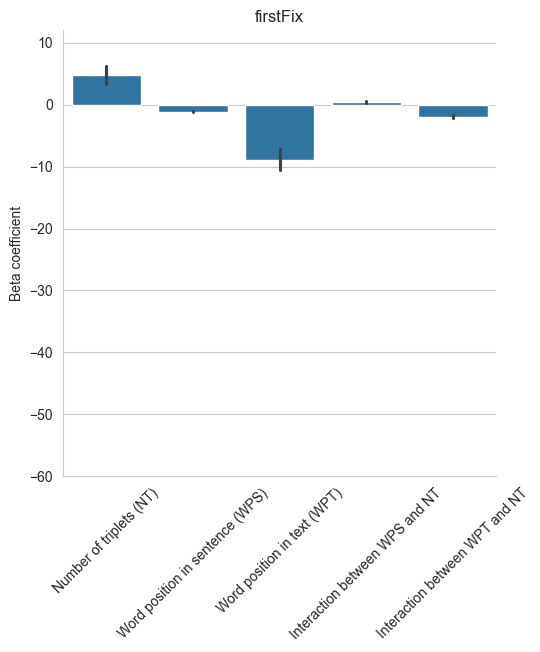

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_29337/1126660089.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  graph.ax.set_xticklabels(['Number of triplets (NT)',


<Figure size 640x480 with 0 Axes>

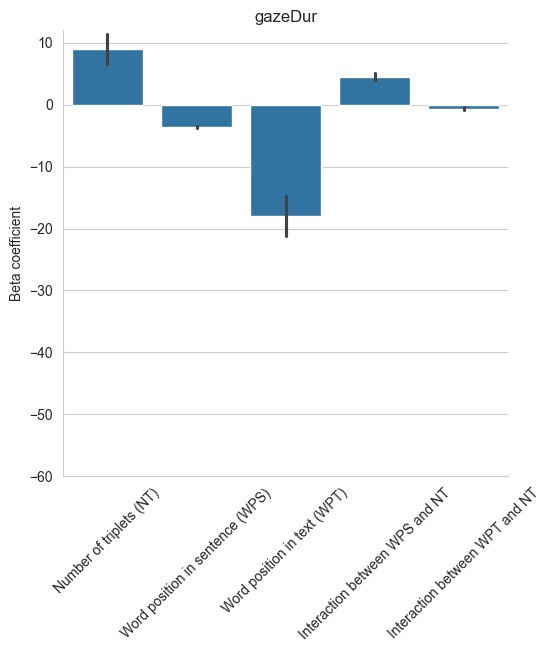

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_29337/1126660089.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  graph.ax.set_xticklabels(['Number of triplets (NT)',


<Figure size 640x480 with 0 Axes>

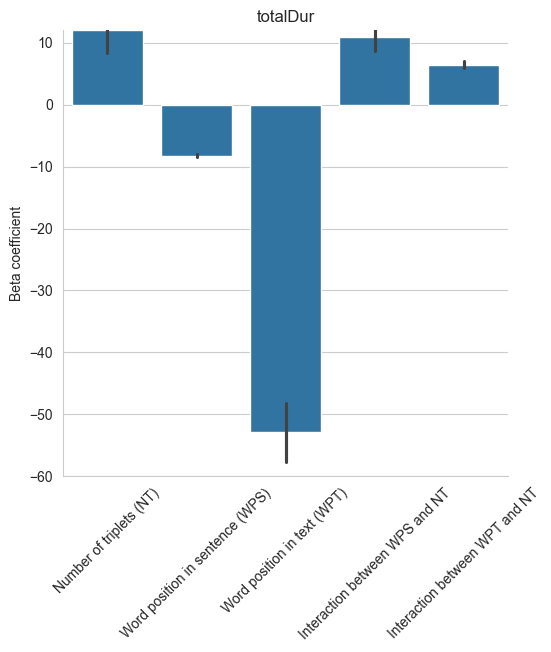

<Figure size 640x480 with 0 Axes>

In [61]:
# Show coefficients and compare corpora for each fixed effect
n_runs = 10
# corpora = ['meco','provo']
corpus = 'meco'
model = 'gpt-4o-mini'
IVs = ['n_triplets', 'norm_word_pos', 'norm_ianum', 'norm_word_pos:n_triplets', 'n_triplets:norm_ianum']
DVs = ['firstFix', 'gazeDur', 'totalDur']

for eye_mov_measure in DV:

    coefficients, factors = [], [] # corpora_col

    # for corpus in corpora:

    for IV in IVs:

        for run in range(1, n_runs+1):

            stats_df = pd.read_csv(f'../data/analysis/{model}/{corpus}/lmer_{eye_mov_measure}Int_{run}.csv')
            coefficient = stats_df[stats_df['term']==IV]['estimate'].values[0]
            coefficients.append(coefficient)
            factors.append(IV)
            # corpora_col.append(corpus)

    # plot_df = pd.DataFrame({'coefficient': coefficients, 'factor': factors, 'corpus': corpora_col})
    # graph = sns.catplot(data=plot_df, x=corpora_col, y=coefficients, col=factors, kind='bar', errorbar='sd', col_wrap=3)
    plot_df = pd.DataFrame({'coefficient': coefficients, 'factor': factors})
    graph = sns.catplot(data=plot_df, x=factors, y=coefficients, kind='bar', errorbar='sd')
    graph.ax.set_xticklabels(['Number of triplets (NT)',
                              "Word position in sentence (WPS)",
                              "Word position in text (WPT)",
                              "Interaction between WPS and NT",
                              "Interaction between WPT and NT"], rotation=45)
    graph.ax.set_ylim(-60, 12)
    plt.title(f'{eye_mov_measure}')
    plt.ylabel('Beta coefficient')
    # plt.tight_layout()
    plt.show()
    plt.clf()

In [ ]:
# TODO Plot effects of n+1 and n-1